<a href="https://colab.research.google.com/github/sarbanibhadra/Premises_on_Biomass_Prediction/blob/main/REO2_AGB_CNN_Log_Model_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# REO2 AGB CNN: log1p target

`USE_LOG_TARGET = True` is the only line that differs between this notebook and its
counterpart. Everything else, including the seed, the split, the epoch count, the
inverse transform wrapper and the evaluation pass, is identical in both files.

Run the cells top to bottom once. Cells marked OPTIONAL are switched off by default
through the flags in the config cell; turn one on only if you want that output.

The test-set predictions are written to a single `.npz` at the end of the inference
cell, and every reported metric is computed from that file. Nothing is evaluated
twice, and no metric can come from a different prediction set than another.

In [ ]:
# Continuation to FM_Create_Patch in GEE in sarbani.memories@gmail.com
!pip install earthengine-api geemap --quiet
import ee
ee.Authenticate()
ee.Initialize(project='project5324-448512')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 40.5 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# =====================================================================
# Configuration and seeding. This is the only cell that differs between
# the two notebooks, and only in the value of USE_LOG_TARGET.
# =====================================================================
import os, random, numpy as np, torch

USE_LOG_TARGET = True      # <-- the ablation switch
RUN_TAG        = 'log'

SEED        = 42
NUM_EPOCHS  = 15          # both notebooks must use the same value
BATCH_SIZE  = 4
LR          = 1e-3
N_TILES     = 380
TRAIN_FRAC  = 0.80
AGB_MAX     = 500.0       # values outside [0, AGB_MAX] are set to 0 (see note below)

# OPTIONAL passes. Each one costs a full sweep over the tiles.
RUN_DATA_CHECK   = False   # NaN check over 5 training batches
EVAL_TRAIN_SET   = True    # train-set bias, needed to separate retransformation
                           # bias from distribution-shift shrinkage
MAKE_FIGURES     = False   # sample prediction panels

# Tile cache. Both notebooks read and write the same cache, so they are
# guaranteed to see byte-identical inputs. The cache stores the cleaned raw
# arrays before any log transform or normalization.
USE_CACHE = True
CACHE_DIR = '/content/drive/MyDrive/reo2_tile_cache'
OUT_DIR   = '/content/drive/MyDrive/reo2_outputs'
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed()

# Separate generator for the DataLoader so that shuffle order does not depend on
# how many times the global RNG has been drawn from elsewhere.
loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)


def seed_worker(worker_id):
    ws = torch.initial_seed() % 2 ** 32
    np.random.seed(ws)
    random.seed(ws)


device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"run tag: {RUN_TAG} | USE_LOG_TARGET={USE_LOG_TARGET} | seed={SEED} | "
      f"epochs={NUM_EPOCHS} | device={device}")
print("note: cuDNN determinism is requested, but transposed convolutions on GPU are "
      "not guaranteed bitwise reproducible. Seeding fixes initialization and shuffle "
      "order, which is what makes the two runs comparable.")

run tag: log | USE_LOG_TARGET=True | seed=42 | epochs=25 | device=cuda
note: cuDNN determinism is requested, but transposed convolutions on GPU are not guaranteed bitwise reproducible. Seeding fixes initialization and shuffle order, which is what makes the two runs comparable.


In [ ]:
import time
from datetime import datetime

def get_tile_dict(index):
    image_asset_id = f'projects/project5324-448512/assets/FM_Patches/320x320_v1/img_tile_{index}'
    mask_asset_id = f'projects/project5324-448512/assets/FM_Patches/320x320_v1/esa_tile_{index}'

    image = ee.Image(image_asset_id)
    mask = ee.Image(mask_asset_id)

    geom = image.geometry().centroid()
    latlon = geom.coordinates().getInfo()
    timestamp = "2018-01-01 00:02:04"
    date_obj = datetime.strptime(timestamp, "%Y-%m-%d %H:%M:%S")

    scale = image.projection().nominalScale()

    region = image.geometry()
    bounds = region.bounds()
    region = ee.Geometry.Polygon(bounds.getInfo()['coordinates'][0])

    return {
        'image': image,
        'mask': mask,
        'lat': latlon[1],
        'lon': latlon[0],
        'time': date_obj,
        'scale': scale,
        'region': region
    }

In [ ]:
import geemap
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm


def crop_center(img, cropx=320, cropy=320):
    # img is [C, H, W]
    y, x = img.shape[1], img.shape[2]
    startx = x // 2 - (cropx // 2)
    starty = y // 2 - (cropy // 2)
    return img[:, starty:starty + cropy, startx:startx + cropx]


def pad_image(img, target_size=(320, 320)):
    # img is [C, H, W]
    c, h, w = img.shape
    pad_h = target_size[0] - h
    pad_w = target_size[1] - w
    pad_left = pad_w // 2
    pad_right = pad_w - pad_left
    pad_top = pad_h // 2
    pad_bottom = pad_h - pad_top
    padded_img = F.pad(torch.tensor(img), (pad_left, pad_right, pad_top, pad_bottom))
    return padded_img.numpy()


def _clean(image_arr, mask_arr):
    image_arr = np.where(np.isneginf(image_arr), 0, image_arr)
    image_arr = np.nan_to_num(image_arr, nan=0.0, posinf=0.0, neginf=0.0)

    mask_arr = np.where(np.isneginf(mask_arr), 0, mask_arr)
    mask_arr = np.nan_to_num(mask_arr, nan=0.0, posinf=0.0, neginf=0.0)
    # Values outside [0, AGB_MAX] are SET TO ZERO, not clipped to the bound.
    # The -9999 invalid sentinel is caught by the < 0 branch. Anything above
    # AGB_MAX also becomes 0, so if the field contains cells above AGB_MAX they
    # are turned into zeros rather than saturated. Check max_agb printed by the
    # statistics cell before interpreting any tail behaviour.
    mask_arr = np.where((mask_arr < 0) | (mask_arr > AGB_MAX), 0.0, mask_arr)
    return image_arr, mask_arr


def fetch_tile_arrays(index):
    """Return cleaned (img [C,H,W], agb [H,W], lat, lon) for a tile.

    Reads the Drive cache when available so that repeated epochs do not re-hit
    Earth Engine, and so that both notebooks train on identical arrays.
    """
    path = os.path.join(CACHE_DIR, f'tile_{index}.npz')
    if USE_CACHE and os.path.exists(path):
        d = np.load(path)
        return d['img'], d['agb'], float(d['lat']), float(d['lon'])

    td = get_tile_dict(index)
    region, scale = td['region'], td['scale']
    image_arr = geemap.ee_to_numpy(td['image'], region=region, scale=scale)
    mask_arr = geemap.ee_to_numpy(td['mask'], region=region, scale=scale)
    image_arr, mask_arr = _clean(image_arr, mask_arr)

    img = np.moveaxis(image_arr, -1, 0)          # [C, H, W]
    agb = mask_arr[:, :, 0]                      # [H, W], Mg/ha

    target_h, target_w = 320, 320
    if img.shape[1] < target_h or img.shape[2] < target_w:
        img = pad_image(img, target_size=(target_h, target_w))
        agb = pad_image(agb[np.newaxis, :, :], target_size=(target_h, target_w)).squeeze()
    else:
        img = crop_center(img, cropx=target_w, cropy=target_h)
        agb = crop_center(agb[np.newaxis, :, :], cropx=target_w, cropy=target_h).squeeze()

    img = img.astype(np.float32)
    agb = agb.astype(np.float32)

    if USE_CACHE:
        np.savez_compressed(path, img=img, agb=agb,
                            lat=td['lat'], lon=td['lon'])
    return img, agb, td['lat'], td['lon']

In [ ]:
def target_transform(agb):
    """Forward transform applied to the label field before z-scoring."""
    return np.log1p(agb) if USE_LOG_TARGET else agb


def to_agb(pred_normalized, mean_msk, std_msk):
    """Invert normalization (and the log transform when it is in use) to Mg/ha.

    Identical in both notebooks. The z-score mean is added back before the
    exponential, which matters for the log branch because expm1 is non-linear.
    Predictions are clipped at zero in both branches so the two models get the
    same treatment; the previous log notebook clipped and the MSE one did not.
    """
    if isinstance(pred_normalized, torch.Tensor):
        pred_normalized = pred_normalized.detach().cpu().numpy()
    x = pred_normalized * float(std_msk) + float(mean_msk)
    agb = np.expm1(x) if USE_LOG_TARGET else x
    return np.clip(agb, 0.0, None)


def compute_dataset_stats(tile_indices):
    """Per-band image mean/std and label mean/std over the given tiles.

    The label statistics are computed on target_transform(agb), so they are
    log-space statistics when USE_LOG_TARGET is True and Mg/ha otherwise.
    """
    band_sums = band_sq = None
    n_img = 0
    msk_sum = msk_sq = 0.0
    n_msk = 0
    max_agb = -np.inf

    for idx in tqdm(tile_indices, desc="Computing dataset statistics"):
        img, agb, _, _ = fetch_tile_arrays(idx)
        max_agb = max(max_agb, float(agb.max()))

        flat_img = img.reshape(img.shape[0], -1).T          # [N, C]
        flat_msk = target_transform(agb).reshape(-1)        # [N]

        if band_sums is None:
            band_sums = np.zeros(flat_img.shape[1], dtype=np.float64)
            band_sq = np.zeros(flat_img.shape[1], dtype=np.float64)

        band_sums += flat_img.sum(axis=0)
        band_sq += (flat_img.astype(np.float64) ** 2).sum(axis=0)
        n_img += flat_img.shape[0]

        msk_sum += flat_msk.sum(dtype=np.float64)
        msk_sq += (flat_msk.astype(np.float64) ** 2).sum()
        n_msk += flat_msk.size

    mean_img = band_sums / n_img
    std_img = np.sqrt(np.maximum(band_sq / n_img - mean_img ** 2, 0.0))
    std_img[std_img == 0] = 1.0

    mean_msk = msk_sum / n_msk
    std_msk = float(np.sqrt(max(msk_sq / n_msk - mean_msk ** 2, 0.0)))
    if std_msk == 0:
        std_msk = 1.0

    print(f"maximum AGB seen across the training tiles: {max_agb:.2f} Mg/ha "
          f"(AGB_MAX = {AGB_MAX}); if this is below AGB_MAX the upper bound never "
          f"took effect")
    return mean_img, std_img, float(mean_msk), std_msk

In [ ]:
class GEDIBiomassDataset(Dataset):
    def __init__(self, tile_indices, mean_img, std_img, mean_msk, std_msk):
        self.tile_indices = tile_indices
        self.mean_img = mean_img
        self.std_img = std_img
        self.mean_msk = mean_msk
        self.std_msk = std_msk

    def __len__(self):
        return len(self.tile_indices)

    def __getitem__(self, idx):
        img, agb, lat, lon = fetch_tile_arrays(self.tile_indices[idx])

        img_n = (img - self.mean_img.reshape(-1, 1, 1)) / self.std_img.reshape(-1, 1, 1)
        msk_n = (target_transform(agb) - self.mean_msk) / self.std_msk

        return {
            'image': torch.tensor(img_n).float(),
            'mask': torch.tensor(msk_n).float().unsqueeze(0),   # [1, H, W]
            'agb': torch.tensor(agb).float().unsqueeze(0),      # raw Mg/ha label
            'lat': torch.tensor(lat).float(),
            'lon': torch.tensor(lon).float(),
        }

In [ ]:
import torch.nn as nn


class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        residual = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)

        out += self.shortcut(residual)
        out = self.relu(out)
        return out


class CNNEncoder(nn.Module):
    def __init__(self, in_channels=8, out_channels=1, dropout_rate=0.25):
        super(CNNEncoder, self).__init__()

        self.initial_conv = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

        self.enc1 = ResBlock(64, 64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.drop1 = nn.Dropout2d(dropout_rate)

        self.enc2 = ResBlock(64, 128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.drop2 = nn.Dropout2d(dropout_rate)

        self.enc3 = ResBlock(128, 256)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.drop3 = nn.Dropout2d(dropout_rate)

        self.enc4 = ResBlock(256, 512)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.drop4 = nn.Dropout2d(dropout_rate)

        self.bottleneck = nn.Sequential(
            ResBlock(512, 1024),
            ResBlock(1024, 1024)
        )

        self.upconv4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = nn.Sequential(ResBlock(1024, 512), ResBlock(512, 512))

        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = nn.Sequential(ResBlock(512, 256), ResBlock(256, 256))

        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = nn.Sequential(ResBlock(256, 128), ResBlock(128, 128))

        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = nn.Sequential(ResBlock(128, 64), ResBlock(64, 64))

        self.output_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        x0 = self.initial_conv(x)

        x1 = self.enc1(x0)
        x_drop = self.drop1(self.pool1(x1))

        x2 = self.enc2(x_drop)
        x_drop = self.drop2(self.pool2(x2))

        x3 = self.enc3(x_drop)
        x_drop = self.drop3(self.pool3(x3))

        x4 = self.enc4(x_drop)
        x_drop = self.drop4(self.pool4(x4))

        bottleneck = self.bottleneck(x_drop)

        x = self.dec4(torch.cat([self.upconv4(bottleneck), x4], dim=1))
        x = self.dec3(torch.cat([self.upconv3(x), x3], dim=1))
        x = self.dec2(torch.cat([self.upconv2(x), x2], dim=1))
        x = self.dec1(torch.cat([self.upconv1(x), x1], dim=1))

        return self.output_conv(x)


print("CNNEncoder model defined with ResNet blocks, dropout, and skip connections (U-Net style).")

CNNEncoder model defined with ResNet blocks, dropout, and skip connections (U-Net style).


In [ ]:
# Tile-level split. Index order, so the test tiles are a contiguous sub-area.
all_tiles_range = list(range(0, N_TILES))
train_end_index = int(len(all_tiles_range) * TRAIN_FRAC)

train_tile_indices = all_tiles_range[:train_end_index]
test_tile_indices = all_tiles_range[train_end_index:]

print(f"Total tiles available: {len(all_tiles_range)}")
print(f"Training tiles: {len(train_tile_indices)} "
      f"(indices {train_tile_indices[0]} to {train_tile_indices[-1]})")
print(f"Test tiles: {len(test_tile_indices)} "
      f"(indices {test_tile_indices[0]} to {test_tile_indices[-1]})")

Total tiles available: 380
Training tiles: 304 (indices 0 to 303)
Test tiles: 76 (indices 304 to 379)


In [ ]:
# Statistics come from the training tiles only. On a cold cache this is the
# slowest cell in the notebook; on a warm cache it reads from Drive.
print("Computing dataset statistics...")
mean_img, std_img, mean_msk, std_msk = compute_dataset_stats(train_tile_indices)
print(f"label mean = {mean_msk:.6f}, label std = {std_msk:.6f} "
      f"({'log space' if USE_LOG_TARGET else 'Mg/ha'})")

train_dataset = GEDIBiomassDataset(train_tile_indices, mean_img, std_img, mean_msk, std_msk)
test_dataset = GEDIBiomassDataset(test_tile_indices, mean_img, std_img, mean_msk, std_msk)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              generator=loader_generator, worker_init_fn=seed_worker)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_dataloader)} | Test batches: {len(test_dataloader)}")

Computing dataset statistics...


Computing dataset statistics: 100%|██████████| 304/304 [08:19<00:00,  1.64s/it]

maximum AGB seen across the training tiles: 483.00 Mg/ha (AGB_MAX = 500.0); if this is below AGB_MAX the upper bound never took effect
label mean = 4.955778, label std = 1.644299 (log space)
Train batches: 76 | Test batches: 19


In [ ]:
# OPTIONAL. Off by default; each batch touches the cache or Earth Engine.
if RUN_DATA_CHECK:
    print("Checking for missing values in the first 5 training batches...")
    found = False
    for batch_idx, data in enumerate(train_dataloader):
        if batch_idx >= 5:
            break
        if torch.isnan(data['image']).any():
            print(f"  Batch {batch_idx}: NaN in 'image'")
            found = True
        if torch.isnan(data['mask']).any():
            print(f"  Batch {batch_idx}: NaN in 'mask'")
            found = True
    print("  No NaNs found." if not found else "  NaNs detected.")
else:
    print("RUN_DATA_CHECK is False, skipping.")

RUN_DATA_CHECK is False, skipping.


In [ ]:
import torch.optim as optim

# Reseed immediately before construction so that both notebooks start from
# identical weights.
set_seed(SEED)

model = CNNEncoder(in_channels=8, out_channels=1, dropout_rate=0.25).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model on {device} | parameters: {n_params:,} | criterion: MSE on "
      f"{'z-scored log1p(AGB)' if USE_LOG_TARGET else 'z-scored AGB'} | lr={LR}")

Model on cuda | parameters: 57,661,953 | criterion: MSE on z-scored log1p(AGB) | lr=0.001


In [ ]:
# =====================================================================
# The one and only training loop. Run this cell once. Re-running it
# continues training the same weights, which is how the previous pair of
# notebooks ended up with different totals.
# =====================================================================
train_losses_per_epoch = []
val_losses_per_epoch = []
NUM_EPOCHS=15
print(f"Training for 15 epochs...")
for epoch in range(15):
    model.train()
    running_train_loss = 0.0
    for data in train_dataloader:
        inputs = data['image'].to(device)
        labels = data['mask'].to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    average_train_loss = running_train_loss / len(train_dataloader)
    train_losses_per_epoch.append(average_train_loss)

    # Held-out loss, tracked for the curve only. No checkpoint is selected on
    # it, so the test tiles do not influence the weights.
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for data in test_dataloader:
            inputs = data['image'].to(device)
            labels = data['mask'].to(device)
            running_val_loss += criterion(model(inputs), labels).item()

    average_val_loss = running_val_loss / len(test_dataloader)
    val_losses_per_epoch.append(average_val_loss)

    print(f'Epoch {epoch + 1}/{NUM_EPOCHS}, Train Loss: {average_train_loss:.4f}, '
          f'Val Loss: {average_val_loss:.4f}')

final_train_loss = train_losses_per_epoch[-1]
final_val_loss = val_losses_per_epoch[-1]
print('Finished training.')

torch.save({'state_dict': model.state_dict(),
            'mean_img': mean_img, 'std_img': std_img,
            'mean_msk': mean_msk, 'std_msk': std_msk,
            'use_log_target': USE_LOG_TARGET, 'seed': SEED,
            'num_epochs': NUM_EPOCHS},
           os.path.join(OUT_DIR, f'model_{RUN_TAG}.pt'))
print(f"weights written to {OUT_DIR}/model_{RUN_TAG}.pt")

Training for 15 epochs...
Epoch 1/15, Train Loss: 0.1131, Val Loss: 0.1237
Epoch 2/15, Train Loss: 0.1171, Val Loss: 0.1936
Epoch 3/15, Train Loss: 0.1159, Val Loss: 0.1094
Epoch 4/15, Train Loss: 0.1185, Val Loss: 0.4092
Epoch 5/15, Train Loss: 0.1040, Val Loss: 0.1074
Epoch 6/15, Train Loss: 0.0975, Val Loss: 0.1429
Epoch 7/15, Train Loss: 0.0984, Val Loss: 0.1301
Epoch 8/15, Train Loss: 0.1067, Val Loss: 0.1032
Epoch 9/15, Train Loss: 0.0925, Val Loss: 0.1385
Epoch 10/15, Train Loss: 0.0864, Val Loss: 0.1295
Epoch 11/15, Train Loss: 0.0948, Val Loss: 0.3028
Epoch 12/15, Train Loss: 0.0882, Val Loss: 0.2557
Epoch 13/15, Train Loss: 0.0779, Val Loss: 0.1011
Epoch 14/15, Train Loss: 0.0769, Val Loss: 0.1089
Epoch 15/15, Train Loss: 0.0779, Val Loss: 0.0968
Finished training.
weights written to /content/drive/MyDrive/reo2_outputs/model_log.pt


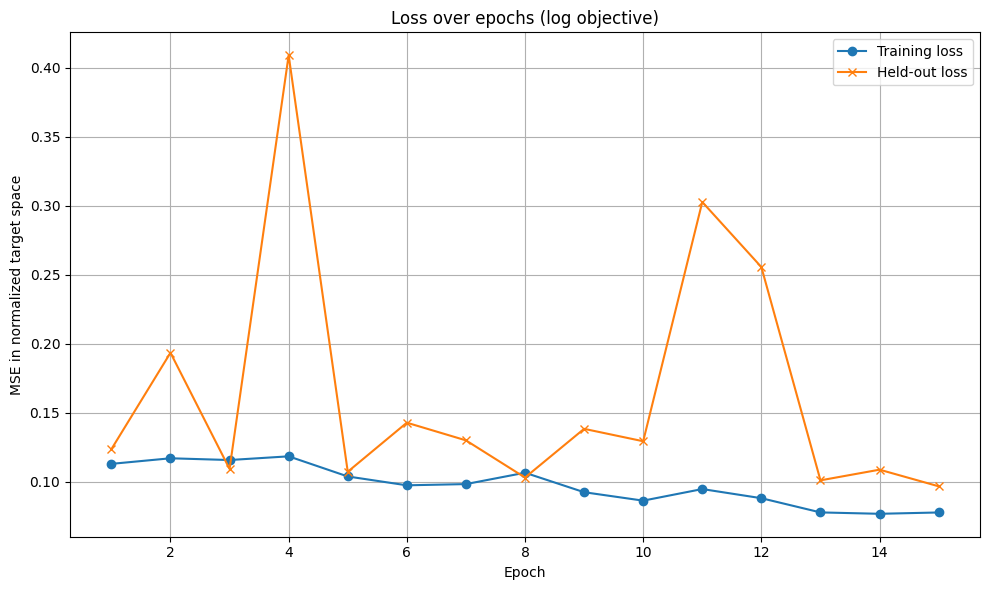

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_losses_per_epoch) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_range, train_losses_per_epoch, label='Training loss', marker='o')
plt.plot(epochs_range, val_losses_per_epoch, label='Held-out loss', marker='x')
plt.title(f'Loss over epochs ({RUN_TAG} objective)')
plt.xlabel('Epoch')
plt.ylabel('MSE in normalized target space')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f'loss_curve_{RUN_TAG}.png'), dpi=150)
plt.show()

In [ ]:
# =====================================================================
# Single inference pass over the test tiles. Predictions and labels are
# written to one file; every number in the results table is computed from
# that file, so no two metrics can come from different prediction sets.
# =====================================================================
model.eval()
pred_norm_chunks, agb_label_chunks = [], []

with torch.no_grad():
    for data in test_dataloader:
        inputs = data['image'].to(device)
        outputs = model(inputs)
        pred_norm_chunks.append(outputs.cpu().numpy())
        agb_label_chunks.append(data['agb'].numpy())      # raw Mg/ha, never transformed

pred_norm = np.concatenate(pred_norm_chunks, axis=0)[:, 0]    # [N, 320, 320]
agb_true = np.concatenate(agb_label_chunks, axis=0)[:, 0]     # [N, 320, 320]
agb_pred = to_agb(pred_norm, mean_msk, std_msk)

pred_path = os.path.join(OUT_DIR, f'test_predictions_{RUN_TAG}.npz')
np.savez_compressed(pred_path,
                    agb_pred=agb_pred.astype(np.float32),
                    agb_true=agb_true.astype(np.float32),
                    tile_indices=np.array(test_tile_indices),
                    mean_msk=mean_msk, std_msk=std_msk,
                    use_log_target=USE_LOG_TARGET, seed=SEED,
                    num_epochs=NUM_EPOCHS)
print(f"predictions for {agb_pred.shape[0]} test tiles written to {pred_path}")

predictions for 76 test tiles written to /content/drive/MyDrive/reo2_outputs/test_predictions_log.npz


In [ ]:
# =====================================================================
# Metrics. Identical code in both notebooks, computed from the saved file.
# Reported twice: per 10 m pixel, and after averaging predictions within
# each 100 m CCI cell, which is the grid the labels actually live on.
# =====================================================================
from sklearn.metrics import mean_absolute_error, r2_score

d = np.load(pred_path)
p, t = d['agb_pred'], d['agb_true']


def block_mean(a, k=10):
    n, h, w = a.shape
    return a.reshape(n, h // k, k, w // k, k).mean(axis=(2, 4))


def report(pred, true, label):
    pred, true = pred.reshape(-1), true.reshape(-1)
    rmse = float(np.sqrt(np.mean((pred - true) ** 2)))
    mae = float(mean_absolute_error(true, pred))
    r2 = float(r2_score(true, pred))
    bias = float(np.mean(pred - true))
    sd = float(np.std(true))
    r2_debiased = r2 + (bias ** 2) / (sd ** 2)
    print(f"--- {label}  (n = {pred.size:,})")
    print(f"    RMSE          {rmse:8.2f} Mg/ha")
    print(f"    MAE           {mae:8.2f} Mg/ha")
    print(f"    R2            {r2:8.4f}")
    print(f"    Bias          {bias:8.2f} Mg/ha")
    print(f"    R2 debiased   {r2_debiased:8.4f}")
    print(f"    label SD      {sd:8.2f} Mg/ha  (= RMSE of the mean-value predictor)")
    return dict(rmse=rmse, mae=mae, r2=r2, bias=bias, r2_debiased=r2_debiased,
                label_sd=sd, n=int(pred.size))


print(f"Objective: {'log1p' if bool(d['use_log_target']) else 'raw'} | "
      f"seed {int(d['seed'])} | {int(d['num_epochs'])} epochs\n")
pixel_metrics = report(p, t, "per 10 m pixel")
print()
cell_metrics = report(block_mean(p), block_mean(t), "per 100 m CCI cell")

import json
with open(os.path.join(OUT_DIR, f'metrics_{RUN_TAG}.json'), 'w') as f:
    json.dump({'run_tag': RUN_TAG, 'use_log_target': bool(d['use_log_target']),
               'seed': int(d['seed']), 'num_epochs': int(d['num_epochs']),
               'pixel': pixel_metrics, 'cell': cell_metrics}, f, indent=2)
print(f"\nmetrics written to {OUT_DIR}/metrics_{RUN_TAG}.json")

Objective: log1p | seed 42 | 15 epochs

--- per 10 m pixel  (n = 7,782,400)
    RMSE             67.33 Mg/ha
    MAE              48.67 Mg/ha
    R2              0.6752
    Bias            -19.13 Mg/ha
    R2 debiased     0.7014
    label SD        118.14 Mg/ha  (= RMSE of the mean-value predictor)

--- per 100 m CCI cell  (n = 77,824)
    RMSE             65.30 Mg/ha
    MAE              47.62 Mg/ha
    R2              0.6945
    Bias            -19.13 Mg/ha
    R2 debiased     0.7207
    label SD        118.14 Mg/ha  (= RMSE of the mean-value predictor)

metrics written to /content/drive/MyDrive/reo2_outputs/metrics_log.json


In [ ]:
import numpy as np
out = '/content/drive/MyDrive/reo2_outputs'
for tag in ['mse', 'log']:
    d = np.load(f'{out}/test_predictions_{tag}.npz')
    p = d['agb_pred'].reshape(-1).astype(np.float64)
    t = d['agb_true'].reshape(-1).astype(np.float64)
    e = p - t
    b = e.mean()
    ae, aed = np.abs(e), np.abs(e - b)
    q = np.percentile(ae, [50, 75, 90, 95, 99])
    print(f'{tag}: MAE {ae.mean():6.2f} | MAE debiased {aed.mean():6.2f} | '
          f'median {q[0]:6.2f} p75 {q[1]:6.2f} p90 {q[2]:6.2f} p95 {q[3]:6.2f} p99 {q[4]:6.2f}')
    print(f'      zero-label fraction {(t == 0).mean():.4f}')

mse: MAE  48.90 | MAE debiased  49.36 | median  36.41 p75  71.36 p90 105.42 p95 126.51 p99 166.86
      zero-label fraction 0.1719
log: MAE  48.67 | MAE debiased  49.56 | median  38.14 p75  75.22 p90 112.45 p95 136.04 p99 187.32
      zero-label fraction 0.1719


In [ ]:
import numpy as np
from sklearn.metrics import r2_score
out = '/content/drive/MyDrive/reo2_outputs'
for tag in ['mse', 'log']:
    d = np.load(f'{out}/test_predictions_{tag}.npz')
    p, t = d['agb_pred'].reshape(-1).astype(np.float64), d['agb_true'].reshape(-1).astype(np.float64)
    m = t > 0
    for name, (pp, tt) in [('all', (p, t)), ('nonzero labels', (p[m], t[m]))]:
        print(f'{tag:4s} {name:15s} n={tt.size:9,d} RMSE {np.sqrt(np.mean((pp-tt)**2)):6.2f} '
              f'MAE {np.abs(pp-tt).mean():6.2f} R2 {r2_score(tt,pp):.4f} '
              f'bias {np.mean(pp-tt):7.2f} SD {tt.std():6.2f}')

mse  all             n=7,782,400 RMSE  62.88 MAE  48.90 R2 0.7167 bias  -12.40 SD 118.14
mse  nonzero labels  n=6,444,500 RMSE  68.04 MAE  54.49 R2 0.1231 bias  -19.54 SD  72.66
log  all             n=7,782,400 RMSE  67.33 MAE  48.67 R2 0.6752 bias  -19.13 SD 118.14
log  nonzero labels  n=6,444,500 RMSE  73.78 MAE  58.34 R2 -0.0311 bias  -23.53 SD  72.66


In [ ]:
import numpy as np, ee, geemap
n_over = n_invalid = n_tot = 0
raw_max = -np.inf
for idx in range(380):
    td = get_tile_dict(idx)
    a = geemap.ee_to_numpy(td['mask'], region=td['region'], scale=td['scale'])[:, :, 0]
    a = np.nan_to_num(a, nan=0.0, posinf=0.0, neginf=0.0)
    valid = a > -9000
    if valid.any():
        raw_max = max(raw_max, float(a[valid].max()))
    n_over += int((a > 500).sum())
    n_invalid += int((~valid).sum())
    n_tot += a.size
    if idx == 303:
        print(f'train: invalid {n_invalid/n_tot:.4f}, above 500 {n_over/n_tot:.6f}')
print(f'all tiles: raw max {raw_max:.2f} | invalid {n_invalid/n_tot:.4f} | above 500 {n_over/n_tot:.6f}')

train: invalid 0.0933, above 500 0.000000
all tiles: raw max 483.00 | invalid 0.1093 | above 500 0.000000


In [ ]:
# OPTIONAL. Train-set bias. Retransformation bias persists inside the training
# distribution; shrinkage caused by the train/test shift does not. Running this
# for both models separates the two mechanisms.
if EVAL_TRAIN_SET:
    eval_train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
    model.eval()
    pn, at = [], []
    with torch.no_grad():
        for data in tqdm(eval_train_loader, desc="train-set pass"):
            pn.append(model(data['image'].to(device)).cpu().numpy())
            at.append(data['agb'].numpy())
    tr_pred = to_agb(np.concatenate(pn, axis=0)[:, 0], mean_msk, std_msk)
    tr_true = np.concatenate(at, axis=0)[:, 0]
    print(f"train-set bias: {np.mean(tr_pred - tr_true):8.2f} Mg/ha")
    print(f"train-set RMSE: {np.sqrt(np.mean((tr_pred - tr_true) ** 2)):8.2f} Mg/ha")
    print(f"train label SD: {np.std(tr_true):8.2f} Mg/ha")
    np.savez_compressed(os.path.join(OUT_DIR, f'train_predictions_{RUN_TAG}.npz'),
                        agb_pred=tr_pred.astype(np.float32),
                        agb_true=tr_true.astype(np.float32))
else:
    print("EVAL_TRAIN_SET is False, skipping.")

In [ ]:
# OPTIONAL. Sample panels. Ground truth is taken from the raw Mg/ha label and
# the prediction from to_agb, so both are on the same scale in both notebooks.
if MAKE_FIGURES:
    import matplotlib.pyplot as plt

    n_show = min(3, p.shape[0])
    fig, axes = plt.subplots(n_show, 2, figsize=(10, n_show * 5), squeeze=False)
    fig.suptitle(f'Test tiles: ground truth and prediction ({RUN_TAG})', fontsize=14)

    for i in range(n_show):
        im = axes[i, 0].imshow(t[i], cmap='viridis', vmin=0, vmax=AGB_MAX)
        axes[i, 0].set_title(f'Tile {test_tile_indices[i]} - CCI AGB')
        axes[i, 0].axis('off')
        fig.colorbar(im, ax=axes[i, 0], fraction=0.046, pad=0.04)

        im = axes[i, 1].imshow(p[i], cmap='viridis', vmin=0, vmax=AGB_MAX)
        axes[i, 1].set_title(f'Tile {test_tile_indices[i]} - predicted AGB')
        axes[i, 1].axis('off')
        fig.colorbar(im, ax=axes[i, 1], fraction=0.046, pad=0.04)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(os.path.join(OUT_DIR, f'samples_{RUN_TAG}.png'), dpi=150)
    plt.show()
else:
    print("MAKE_FIGURES is False, skipping.")